In [29]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft3d import dft_core
from cdft.lj_eos import lj_eos

torch.set_default_dtype(torch.float64)
pi = np.pi

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [ ]:
def build_test_particle_field(L, n, sigma, epsilon, cutoff=50.0):
    
    cell = L/n
    ax = (np.arange(n)+0.5)*cell
    c = 0.5*L
    dd = [ax-c]*3
    dd = [x-L*np.round(x/L) for x in dd]          # imagem minima
    r = np.sqrt(dd[0][:, None, None]**2
                + dd[1][None, :, None]**2
                + dd[2][None, None, :]**2)

    # r = 0 no centro: evita divisao por zero. O valor nao importa,
    # porque esses pontos entram na regiao excluida de qualquer forma.
    rs = np.clip(r, 0.3*sigma, None)
    V = 4.0*epsilon*((sigma/rs)**12-(sigma/rs)**6)
    V = np.clip(V, None, 1e6)                     # evita inf antes do corte
    return V, r

In [ ]:
def radial_average(field, r, dr, r_max, weights=None):
    
    nb = int(np.floor(r_max/dr))
    idx = np.floor(r.ravel()/dr).astype(int)
    f = field.ravel()
    m = idx < nb
    idx, f = idx[m], f[m]
    w = np.ones_like(f) if weights is None else weights.ravel()[m]
    num = np.bincount(idx, weights=f*w, minlength=nb)
    den = np.bincount(idx, weights=w, minlength=nb)
    r_c = (np.arange(nb)+0.5)*dr
    out = np.full(nb, np.nan)
    ok = den > 0
    out[ok] = num[ok]/den[ok]
    return r_c, out, den

In [17]:
sigma, epsilon = 1.0, 1.0
parameters = {'sigma': sigma, 'epsilon': epsilon}
T = 0.75                      
rho_bulk = 0.84
n = 128

L = 7.0*sigma
dz = L/n

dr = dz

if dz > 0.06*sigma:
    print('AVISO: dz = %.3f sigma. O primeiro pico de g(r) e estreito;'
            % (dz/sigma))
    print('       abaixo de 0.05 sigma a altura do pico fica subestimada.')
if L < 6.0*sigma:
    print('AVISO: L = %.1f sigma. Com menos de ~6 sigma a particula de'
            % (L/sigma))
    print('       teste interage com as proprias imagens periodicas.')

V, r = build_test_particle_field(L, n, sigma, epsilon)

dev = torch.device('cpu')
dft = dft_core(parameters, T,
                np.array([L, L, L]), None, np.array([n, n, n]), dev)

rho_b = torch.tensor([float(rho_bulk)])
dft.initial_condition(rho_b, torch.tensor(V, device=dev),
                        potential_cutoff=50.0, model='bulk')
dft.equilibrium_density_profile(rho_b, fmt='ASWB', solver='anderson', 
                                anderson_mmax=5, anderson_damping=0.1, 
                                tol=1e-8, max_it=2000, logoutput=True)

0 1.23223874626799
1 1.1154710592498311
2 0.9143561382710842
3 0.6357367191256157
4 0.6524202503123258
5 0.3430289692154115
6 0.1278339522357986
7 0.06907368043305769
8 0.04225715719085722
9 0.03127328066634832
10 0.026375387792287673
11 0.02380028215258742
12 0.020801764032653502
13 0.018161206126321747
14 0.015410097446432996
15 0.015555671820721468
16 0.012514598432996656
17 0.012446655225117275
18 0.011333086425643358
19 0.01009076357054135
20 0.008582521671409113
21 0.008291284561761893
22 0.006941854215545611
23 0.006071794750751371
24 0.005523549246480588
25 0.004899878192369338
26 0.003916118829956731
27 0.0035411556023296734
28 0.003183829382336046
29 0.002852322282159112
30 0.0026130543320689657
31 0.0025007745124273526
32 0.002143249504099801
33 0.0019312666323869846
34 0.0016971886567562135
35 0.00137196873954297
36 0.0013505670346740165
37 0.0012576453316152456
38 0.001216056439384129
39 0.0010575735887030221
40 0.0009013596172461071
41 0.0007523014390606278
42 0.000664567

In [41]:
rho = dft.rho.detach().cpu().numpy()
g3d = rho/float(rho_bulk)
r_c, g, cnt = radial_average(g3d, r, dr, 6.0)

/tmp/ipykernel_501220/1763140456.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16, frameon=False, edgecolor='k')


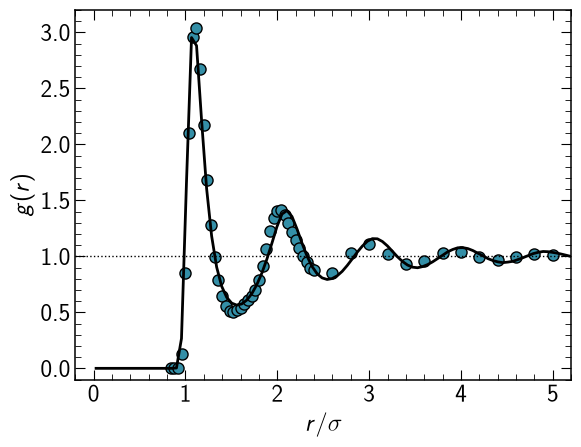

In [45]:
import matplotlib.pyplot as plt

data = np.loadtxt('data/lj-radialdistribution-rho0.84-T0.75.dat', skiprows=1)

plt.plot(data[:,0], data[:,1], 'o', color=colors[3], mew=1.0, ms=8, mec='k')
plt.plot(r_c, g, '-', color='k', lw=2.0)
plt.axhline(1.0, color='k', lw=1.0, ls=':')
plt.xlabel(r'$r/\sigma$', fontsize=18)
plt.ylabel(r'$g(r)$', fontsize=18)
plt.xlim((-0.2,5.2))
plt.ylim((-0.1, 3.2))
plt.minorticks_on()

plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')